# Nucleus 1000 ins data to keypoints

In [1]:
import numpy as np
import pandas as pd
from tools.bag_to_df import bag_topic_to_dataframe
import matplotlib.pyplot as plt 
from tools.tools import *
from dataclasses import dataclass
from scipy.spatial.transform import Rotation as R
from tools.tools import print_bag_topics


%load_ext autoreload
%autoreload 2

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Load BAG

In [2]:
bagdir = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_data.bag"
print_bag_topics(bagdir)

Topics and message types:
/bluerov2/alive                                std_msgs/msg/Float32
/bluerov2/armed                                std_msgs/msg/Float32
/bluerov2/battery                              messages/msg/BatteryStatus
/bluerov2/modes                                joystick/msg/ModeManager2
/commanded_thrust                              rospy_tutorials/msg/Floats
/controller/x                                  messages/msg/MRACOupdate
/controller/y                                  messages/msg/MRACOupdate
/controller/yaw                                messages/msg/PIDState
/controller/z                                  messages/msg/PIDState
/gui/netFollowing_manager                      messages/msg/NetFollowingManager
/guidance                                      messages/msg/GuidanceManager
/joystick                                      joystick/msg/Joystick
/joystick/dvl_reset_position                   messages/msg/BoolStamped
/joystick/init                        

# Read data

In [3]:
ins_df = bag_topic_to_dataframe(bagdir, topic="/nucleus1000dvl/ins")
# Add roll pitch yaw to ins data
quats = ins_df[["quaternion.x", "quaternion.y", "quaternion.z", "quaternion.w"]].values
eulers = R.from_quat(quats).as_euler('xyz', degrees=False)
ins_df["roll"] = eulers[:, 0]
ins_df["pitch"] = eulers[:, 1]
ins_df["yaw"] = eulers[:, 2]


dvl_position = bag_topic_to_dataframe(bagdir, topic="/sensor/dvl_position")
dvl_velocity = bag_topic_to_dataframe(bagdir, topic="/sensor/dvl_velocity")
nucleus_altitude = bag_topic_to_dataframe(bagdir, topic="/nucleus1000dvl/altimeter")
plane_position = bag_topic_to_dataframe(bagdir, topic="/navigation/plane_approximation_position")
plane_approximation = bag_topic_to_dataframe(bagdir, topic="/navigation/plane_approximation")
plane_position.info()

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269 entries, 0 to 268
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   t                         269 non-null    float64
 1   __msgtype__               269 non-null    object 
 2   header.__msgtype__        269 non-null    object 
 3   header.frame_id           0 non-null      float64
 4   header.seq                269 non-null    int64  
 5   header.stamp.__msgtype__  269 non-null    object 
 6   header.stamp.nanosec      269 non-null    int64  
 7   header.stamp.sec          269 non-null    int64  
 8   pitch                     269 non-null    float64
 9   roll                      269 non-null    float64
 10  t_last_reset              269 non-null    float64
 11  time                      269 non-null    float64
 12  x                         269 non-null    float64
 13  y                         269 non-null    float64
 14  yaw       

```

world | old dvl | nucleus

x_w   =  z_0    = -y_1
y_w   = -x_0    = -x_1
z_w   = -y_0    =  z_1

roll  =  yaw_0   = pitch_1
pitch = -roll_0  = -(roll_1 + pi/2)
yaw   = -pitch_0 = yaw_1

```


In [9]:
#  Params
average_every = 20

# Avereage every
df = ins_df
usable_len = (len(df) // average_every) * average_every
df = df.iloc[:usable_len].copy()
groups = df.groupby(df.index // average_every, sort=True).mean(numeric_only=True)

# Start at t = 0
t0 = groups["t"].iloc[0]
groups["t"] -= t0


# Add roll pitch yaw columns
quats = groups[["quaternion.x", "quaternion.y", "quaternion.z", "quaternion.w"]].values
eulers = R.from_quat(quats).as_euler('xyz', degrees=False)
groups["roll"] = eulers[:, 0]
groups["pitch"] = eulers[:, 1]
groups["yaw"] = eulers[:, 2]



#Build keypoints
xyz_out, rpy_out, time_out = [], [], []

for i, row in groups.iterrows():
    # get current ins data
    x_pos = float(row["positionFrame.x"])
    y_pos = float(row["positionFrame.y"])
    z_pos = float(row["positionFrame.z"])

    roll = float(row["roll"])
    pitch = float(row["pitch"])
    yaw = float(row["yaw"])

    t = float(row["t"])

    # Map coordinates
    x_w = y_pos
    y_w = -x_pos
    z_w = z_pos

    roll_w = pitch
    pitch_w = -(roll + np.pi/2)
    yaw_w = yaw

    xyz = np.array([x_w, y_w, z_w])
    rpy = np.array([roll_w, pitch_w, yaw_w])


    xyz_out.append(xyz)
    rpy_out.append(rpy)
    time_out.append(t)

# Gaussian filtering

In [ ]:
from scipy.ndimage import gaussian_filter1d

win_sec = 0.8 # Window size

df = ins_df.copy()

t = df["t"].to_numpy()
t0 = t[0]
t -= t0
dt = np.median(np.diff(t)) if len(t) > 1 else 0.01
fs = 1.0 / max(dt, 1e-6)

# Positions in sensor frame
x = df["positionFrame.x"].to_numpy(dtype=float)
y = df["positionFrame.y"].to_numpy(dtype=float)
z = df["positionFrame.z"].to_numpy(dtype=float)

# Orientation in sensor frame
quats = df[["quaternion.x","quaternion.y","quaternion.z","quaternion.w"]].to_numpy(dtype=float)
eul = R.from_quat(quats).as_euler('xyz', degrees=False)
roll, pitch, yaw = eul[:,0], eul[:,1], eul[:,2]

# Unwrap vinkler for å unngå hopp ved ±pi
roll_u  = np.unwrap(roll)
pitch_u = np.unwrap(pitch)
yaw_u   = np.unwrap(yaw)


def lp_gauss(sig):
    sigma = (win_sec / 2.355) * fs
    return gaussian_filter1d(sig, sigma=sigma, mode='nearest')

# Glatt posisjon uten faseforsinkelse
x_s = lp_gauss(x); y_s = lp_gauss(y); z_s = lp_gauss(z)

roll_s  = np.angle(np.exp(1j * lp_gauss(roll_u)))
pitch_s = np.angle(np.exp(1j * lp_gauss(pitch_u)))
yaw_s   = np.angle(np.exp(1j * lp_gauss(yaw_u)))

# ----- Map coords -----
x_w =  y_s
y_w = -x_s
z_w =  z_s

roll_w  =  pitch_s
pitch_w = -(roll_s + np.pi/2)
yaw_w   =  yaw_s

xyz_out  = np.c_[x_w, y_w, z_w]
rpy_out  = np.c_[roll_w, pitch_w, yaw_w]
time_out = t


# Transform positions to match net

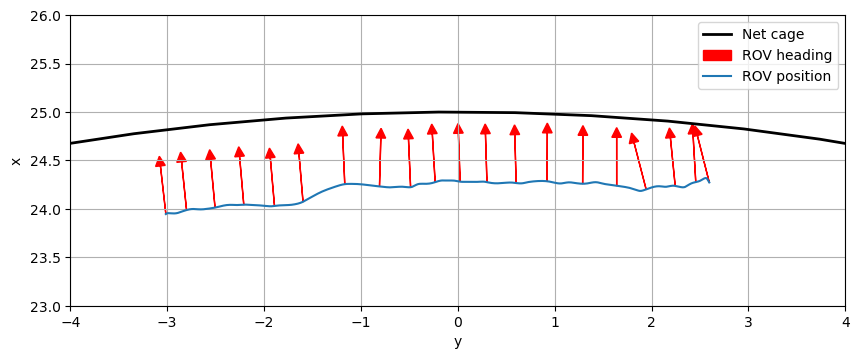

Rotation matrix
[[ 0.85252452  0.52268723  0.        ]
 [-0.52268723  0.85252452 -0.        ]
 [-0.          0.          1.        ]]


In [16]:
# transformation
cg_to_dvl = 0.153

xyz_post = np.array([23.69 - cg_to_dvl, 4.5, 0])
rpy_post = np.array([0, 0, -0.55])

R_post = R.from_euler('xyz', rpy_post)

xyz_transformed, rpy_transformed = [], []

for xyz, rpy in zip(xyz_out, rpy_out):
    # Rotate and translate
    xyz_w = R_post.apply(xyz) + xyz_post
    xyz_transformed.append(xyz_w)
    
    R_body = R.from_euler('xyz', rpy)
    R_total = R_post * R_body

    rpy_transformed.append(R_total.as_euler('xyz'))

xyz_transformed = np.array(xyz_transformed)
rpy_transformed = np.array(rpy_transformed)

x_list, y_list, z_list = xyz_transformed[:,0], xyz_transformed[:,1], xyz_transformed[:,2]
roll_list, pitch_list, yaw_list = rpy_transformed[:, 0], rpy_transformed[:, 1], rpy_transformed[:, 2]

# --- Plt Net ---
r = 25
cx, cy = 0, 0
theta = np.linspace(0, 2*np.pi, 200)
x = cx + r * np.cos(theta)
y = cy + r * np.sin(theta)

plt.figure(figsize=(10,10))
plt.grid()
plt.plot(x, y, color="black", linewidth=2, label="Net cage")

# --- Plot Arrows ---
n_arrows = 20
arrow_len = 0.5
idx = np.linspace(0, len(x_list)-1, n_arrows, dtype=int)

for i in idx:
    yaw = yaw_list[i]
    dx = arrow_len * np.cos(yaw)
    dy = arrow_len * np.sin(yaw)

    label = "ROV heading" if i == 0 else None

    plt.arrow(y_list[i], x_list[i],
              dy, dx,
              head_width=0.1, head_length=0.1,
              fc='r', ec='r', label=label)


plt.plot(y_list, x_list, label="ROV position")

plt.xlabel("y")
plt.ylabel("x")

plt.ylim(23, 26)
plt.xlim(-4, 4)

plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

print("Rotation matrix")
print(R_post.as_matrix())

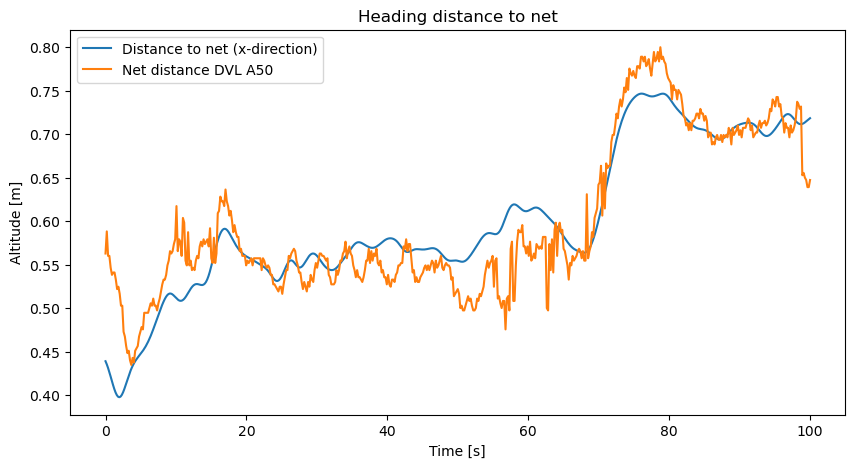

In [13]:
# Plot distance to net

def dist_to_net(y_pos):
    r = 25
    return np.sqrt(r**2 - y_pos**2)

dist = []

for x, y in zip(x_list, y_list):
    
    distance = dist_to_net(y) - x - cg_to_dvl
    dist.append(distance)

dvl_altitude = dvl_velocity["altitude"].values

plt.figure(figsize=(10, 5))
plt.title("Heading distance to net")
plt.plot(np.linspace(0, 100, len(x_list)), dist, label="Distance to net (x-direction)")
plt.plot(np.linspace(0, 100, len(dvl_altitude)), dvl_altitude, label="Net distance DVL A50")
plt.xlabel("Time [s]")
plt.ylabel("Altitude [m]")
plt.legend()


# To file

In [8]:
output_file = "keypoints.txt"

fmt = lambda v: f"{v:.4f}"
lines = []
for t, x, y, z, roll, pitch, yaw in zip(time_out, x_list, y_list, z_list, roll_list, pitch_list, yaw_list):
    line = (
        f'<keypoint time="{fmt(t)}" '
        f'xyz="{fmt(x)} {fmt(y)} {fmt(z)}" '
        f'rpy="{fmt(roll)} {fmt(pitch)} {fmt(yaw)}"/>'
    )
    lines.append(line)

with open(output_file, "w") as f:
    f.write("\n".join(lines))

print(f"Wrote {len(lines)} keypoints to {output_file}")

Wrote 562 keypoints to keypoints.txt
